In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.tsa.seasonal as sm
import yfinance as yf

In [3]:
ação = yf.Ticker("PETR4.SA")
df = ação.history(period="1y", interval='1d')
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-02 00:00:00-03:00,32.712906,33.314711,32.506318,33.027283,30046800,0.000000,0.0
2025-01-03 00:00:00-03:00,33.126082,33.269795,32.623081,32.676975,23314200,0.000000,0.0
2025-01-06 00:00:00-03:00,32.874579,32.955418,32.389547,32.524277,23760200,0.000000,0.0
2025-01-07 00:00:00-03:00,32.829673,33.458422,32.605119,33.215904,37753300,0.000000,0.0
2025-01-08 00:00:00-03:00,33.224889,33.341654,32.721888,32.946442,24483500,0.000000,0.0
...,...,...,...,...,...,...,...
2025-12-23 00:00:00-03:00,30.549999,30.570000,30.200001,30.309999,35703900,0.943208,0.0
2025-12-26 00:00:00-03:00,30.309999,30.430000,30.120001,30.410000,20178600,0.000000,0.0
2025-12-29 00:00:00-03:00,30.559999,30.809999,30.520000,30.730000,20588100,0.000000,0.0


In [7]:
decomposição = sm.seasonal_decompose(df['Close'], model='additive', period=30)
decomposição

<Axes: title={'center': 'Preço de Fechamento da PETR4'}, xlabel='Date'>

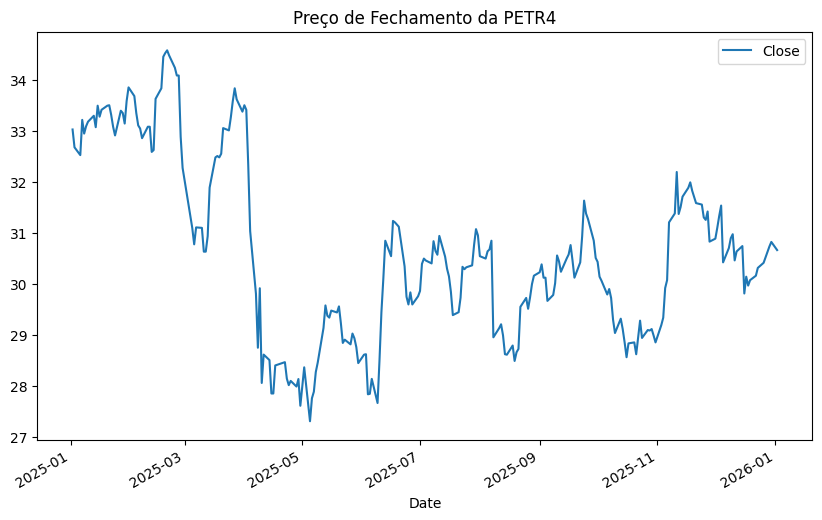

In [8]:
df[["Close"]].plot(title="Preço de Fechamento da PETR4", figsize=(10, 6))

In [9]:
decomposição.seasonal + decomposição.trend + decomposição.resid

Date
2025-01-02 00:00:00-03:00   NaN
2025-01-03 00:00:00-03:00   NaN
2025-01-06 00:00:00-03:00   NaN
2025-01-07 00:00:00-03:00   NaN
2025-01-08 00:00:00-03:00   NaN
                             ..
2025-12-23 00:00:00-03:00   NaN
2025-12-26 00:00:00-03:00   NaN
2025-12-29 00:00:00-03:00   NaN
2025-12-30 00:00:00-03:00   NaN
2026-01-02 00:00:00-03:00   NaN
Length: 251, dtype: float64

<Axes: title={'center': 'Residual'}, xlabel='Date'>

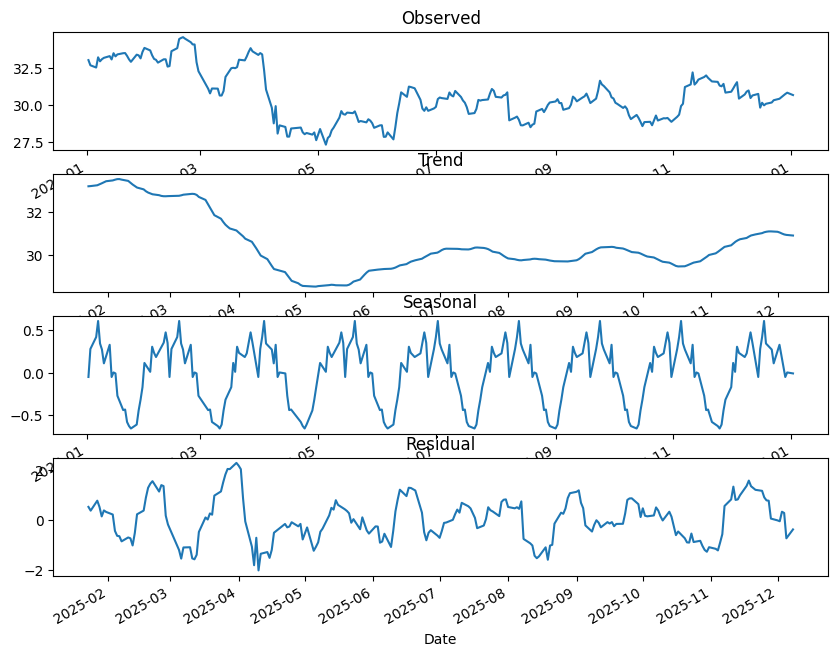

In [10]:
ax, fig =plt.subplots(4,1, figsize=(10,8))
decomposição.observed.plot(ax=fig[0], title='Observed')
decomposição.trend.plot(ax=fig[1], title='Trend')
decomposição.seasonal.plot(ax=fig[2], title='Seasonal')
decomposição.resid.plot(ax=fig[3], title='Residual')

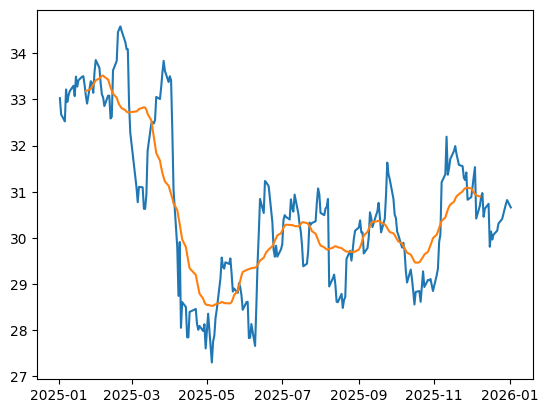

In [13]:
plt.plot(decomposição.observed)
plt.plot(decomposição.trend)

In [14]:
media_movel7d = df['Close'].rolling(window=7).mean()
media_movel15d = df['Close'].rolling(window=15).mean()
media_movel30d = df['Close'].rolling(window=30).mean()


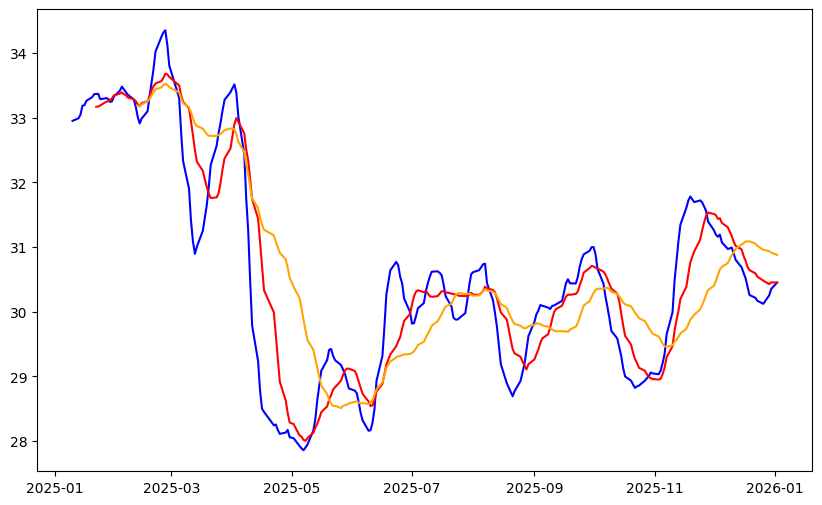

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(media_movel7d, 'blue')
plt.plot(media_movel15d, 'red')
plt.plot(media_movel30d, 'orange')

In [22]:
df ['year'] = df.index.year
df ['month'] = df.index.month
df ['day'] = df.index.day
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day
Date,,,,,,,,,,
2025-01-02 00:00:00-03:00,32.712906,33.314711,32.506318,33.027283,30046800,0.0,0.0,2025,1,2
2025-01-03 00:00:00-03:00,33.126082,33.269795,32.623081,32.676975,23314200,0.0,0.0,2025,1,3
2025-01-06 00:00:00-03:00,32.874579,32.955418,32.389547,32.524277,23760200,0.0,0.0,2025,1,6
2025-01-07 00:00:00-03:00,32.829673,33.458422,32.605119,33.215904,37753300,0.0,0.0,2025,1,7
2025-01-08 00:00:00-03:00,33.224889,33.341654,32.721888,32.946442,24483500,0.0,0.0,2025,1,8


In [23]:
df['rentabilidade'] = df['Close'].pct_change() * 100
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,rentabilidade
Date,,,,,,,,,,,
2025-01-02 00:00:00-03:00,32.712906,33.314711,32.506318,33.027283,30046800,0.0,0.0,2025,1,2,NaN
2025-01-03 00:00:00-03:00,33.126082,33.269795,32.623081,32.676975,23314200,0.0,0.0,2025,1,3,-1.060661
2025-01-06 00:00:00-03:00,32.874579,32.955418,32.389547,32.524277,23760200,0.0,0.0,2025,1,6,-0.467297
2025-01-07 00:00:00-03:00,32.829673,33.458422,32.605119,33.215904,37753300,0.0,0.0,2025,1,7,2.126496
2025-01-08 00:00:00-03:00,33.224889,33.341654,32.721888,32.946442,24483500,0.0,0.0,2025,1,8,-0.811246


Text(0, 0.5, 'Rentabilidade (%)')

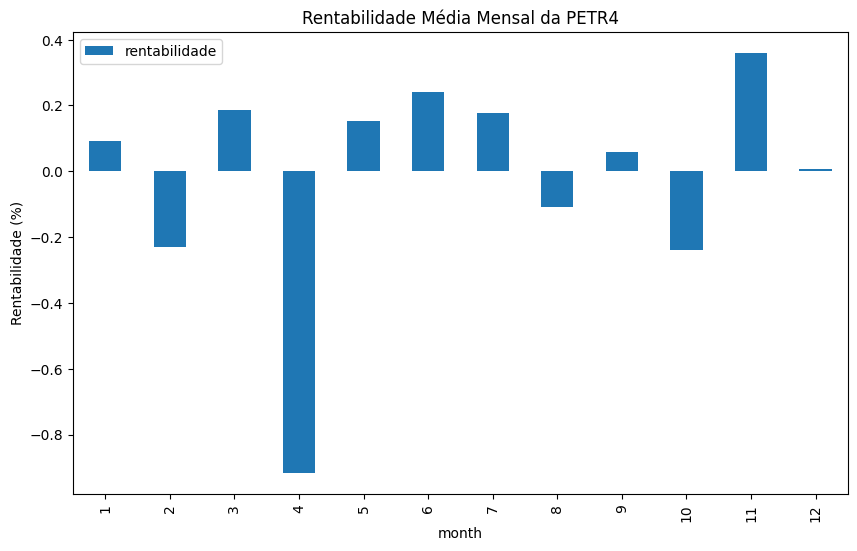

In [25]:
df.groupby('month').agg({'rentabilidade': 'mean'})\
.plot(kind='bar', title='Rentabilidade Média Mensal da PETR4', figsize=(10,6))\
.set_ylabel('Rentabilidade (%)')